# SKaiNET - MNIST Dataset PoC

In [44]:
@file:DependsOn("sk.ainet.app:kotlin-notebook:0.29.1")
@file:DependsOn("org.jetbrains.kotlinx:kotlinx-coroutines-core:1.8.1")

In [45]:
import kotlinx.coroutines.runBlocking
import sk.ainet.context.DefaultDataExecutionContext
import sk.ainet.context.DirectCpuExecutionContext
import sk.ainet.data.mnist.MNISTConstants
import sk.ainet.data.mnist.MNISTLoaderConfig
import sk.ainet.data.mnist.MNISTLoaderFactory
import sk.ainet.lang.tensor.Shape
import sk.ainet.lang.types.Int8
import kotlin.random.Random

val imageTensor = runBlocking {
    // always ignore cache to force download as requested
    val config = MNISTLoaderConfig(
        useCache = true
    )

    val loader = MNISTLoaderFactory.create(config)

    // 1) Download training dataset
    val trainDataset = loader.loadTrainingData()
    // 2) Create a train/test split (80/20)
    val (trainSplit, testSplit) = trainDataset.shuffle().split(0.8)
    // 3) Pick a random image from the train split and convert to a tensor
    Random(100)
    val idx = Random(24).nextInt(trainSplit.xSize)
    val sample = trainSplit.getX(idx)

    // Convert to an Int8 tensor with shape [1, 28, 28]
    val ctx = DirectCpuExecutionContext ()
    val shape = Shape(1, MNISTConstants.IMAGE_SIZE, MNISTConstants.IMAGE_SIZE)
    val tensor = ctx.fromByteArray<Int8, Byte>(shape, Int8::class, sample.image)
    tensor
}

Using cached file: mnist-data/train-images-idx3-ubyte
Using cached file: mnist-data/train-labels-idx1-ubyte


In [46]:
import sk.ainet.app.notebook.tools.Layout
import sk.ainet.app.notebook.tools.toImage

imageTensor.toImage(Layout.CHW)

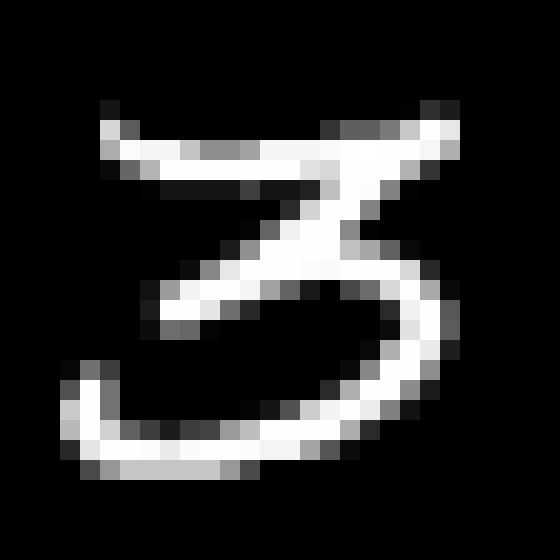

In [47]:
import sk.ainet.app.notebook.tools.UpsampleNearestNeighbor.upscaleNearest

val ctx = DefaultDataExecutionContext()
val bigger = upscaleNearest(imageTensor, 20, Layout.CHW,  ctx)
bigger.toImage(Layout.CHW)


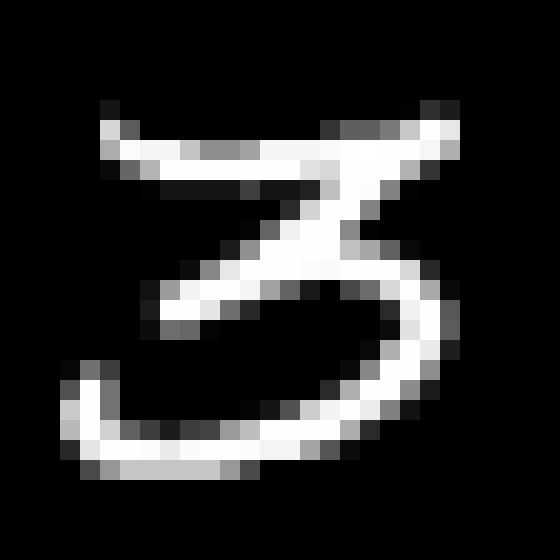
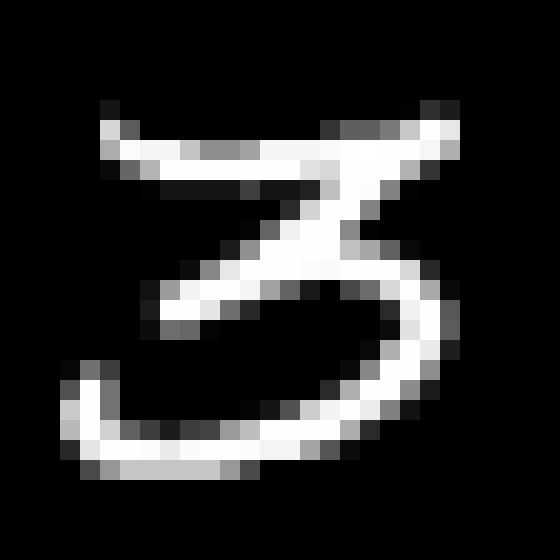
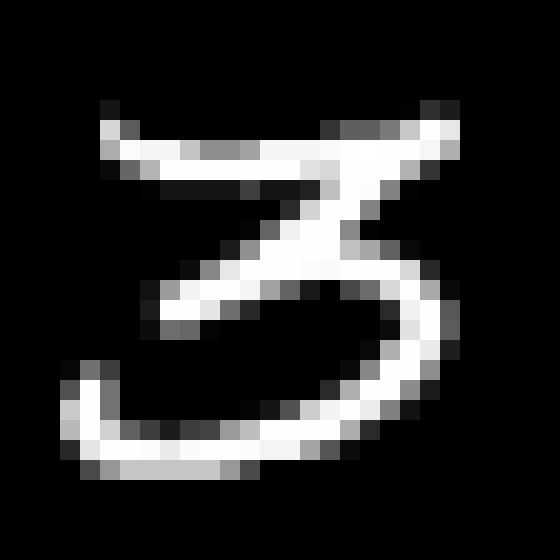

In [48]:
import sk.ainet.app.notebook.display.renderGrid

var aa = bigger.toImage(Layout.CHW)
HTML(renderGrid(listOf(aa, aa, aa)).toString())

In [49]:
import sk.ainet.lang.tensor.Tensor
/**
 * Converts a [1, H, W] single-channel image tensor to scatter-plot arrays (x, y, color).
 * - x: IntArray of x-coordinates in [0, W)
 * - y: IntArray of y-coordinates in [0, H)
 * - color: FloatArray normalized to 0..1 derived from unsigned byte value
 */
fun toScatterXYColor(t: Tensor<Int8, Byte>): Triple<IntArray, IntArray, FloatArray> {
    require(t.shape.rank == 3 && t.shape.dimensions[0] == 1) { "Expected shape [1, H, W], got ${t.shape}" }
    val h = t.shape.dimensions[1]
    val w = t.shape.dimensions[2]
    val n = h * w
    val xs = IntArray(n)
    val ys = IntArray(n)
    val colors = FloatArray(n)

    var i = 0
    for (yy in 0 until h) {
        for (xx in 0 until w) {
            xs[i] = xx
            ys[i] = yy
            val b: Byte = t.data[0, yy, xx]
            val u = b.toInt() and 0xFF
            colors[i] = u / 255f
            i++
        }
    }
    return Triple(xs, ys, colors)
}

In [50]:
val (x_value,y_value,c) = toScatterXYColor(imageTensor)

In [51]:
%use kandy

In [52]:
plot {
    points {
        x(x_value.toList())
        y(y_value.toList())
        color(c.asList())     // numeric -> continuous color scale
        size = 1.0            // small points for pixel-like display
        alpha = 1.0
    }
    layout {
        title = "Main Title"
        style {
            xAxis.ticks {
                null
            }
        }
        xAxisLabel = ""
        yAxisLabel = ""
        style(Style.Grey)
    }
}

<head>
 <meta charset="UTF-8">
 <style> html, body { margin: 0; overflow: hidden; } </style>
 <script type="text/javascript" data-lets-plot-script="library" src="https://cdn.jsdelivr.net/gh/JetBrains/lets-plot@v4.5.1/js-package/distr/lets-plot.min.js"></script>
 </head>
 <body>
 <div id="YokDgE"></div>
 <script type="text/javascript" data-lets-plot-script="plot">
 
 (function() {
 // ----------
 
 var plotSpec={
"ggtitle":{
"text":"Main Title"
},
"mapping":{
},
"guides":{
"x":{
"title":""
},
"y":{
"title":""
}
},
"data":{
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"color",
"scale_mapper_kind":"color_gradient",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"color":"color"
},
"stat":"identity",
"data":{
"color":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0784313753247261,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007843137718737125,0.1882352977991104,0.10980392247438431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8392156958580017,0.35686275362968445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.20000000298023224,0.37254902720451355,0.37254902720451355,0.47843137383461,0.7843137383460999,0.9960784316062927,0.9058823585510254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6745098233222961,0.9843137264251709,0.9607843160629272,0.9607843160629272,0.7686274647712708,0.5529412031173706,0.5529412031173706,0.6352941393852234,0.9607843160629272,0.9607843160629272,0.9607843160629272,0.9803921580314636,0.9960784316062927,1.0,0.9960784316062927,0.9960784316062927,0.9647058844566345,0.686274528503418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03921568766236305,0.4000000059604645,0.7019608020782471,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.8823529481887817,0.843137264251709,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.6980392336845398,0.20392157137393951,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0117647061124444,0.0784313753247261,0.0784313753247261,0.0784313753247261,0.0784313753247261,0.24705882370471954,0.0784313753247261,0.0784313753247261,0.12941177189350128,0.7450980544090271,0.9960784316062927,0.9882352948188782,0.5098039507865906,0.0117647061124444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.16470588743686676,0.8274509906768799,0.9960784316062927,0.9960784316062927,0.5137255191802979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01568627543747425,0.3921568691730499,0.9411764740943909,0.9960784316062927,0.9960784316062927,0.5333333611488342,0.0117647061124444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10588235408067703,0.5647059082984924,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.7529411911964417,0.6549019813537598,0.3803921639919281,0.03529411926865578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0470588244497776,0.529411792755127,0.9058823585510254,0.9960784316062927,0.9960784316062927,0.9960784316062927,0.9843137264251709,0.9764705896377563,0.9921568632125854,0.9960784316062927,0.9960784316062927,0.843137264251709,0.16078431904315948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06666667014360428,0.6117647290229797,0.9529411792755127,0.9960784316062927,0.9960784316062927,0.95686274766922,0.635294139385223